## Load notebook parameters

In [1]:
### LIBRARIES ###
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'], plt.rcParams['axes.labelsize'] = 14, 18
import seaborn as sns
import plotly.graph_objects as go
import pandas as pd
import os, sys

sys.path.append('./XPCSlibrary/')
from XPCStools import get_g2mt_fromling2

###### FOLDER PATHS ######
from folder_paths import *

### Load data

In [2]:
######## LOAD SCAN_INFO.CSV ###########
scan_info = pd.read_csv('../PROCESSED_DATA/scan_info.csv', comment='#')
scan_info = scan_info.set_index('scan')

############# LOAD FIT OUT #############

# get file names
g2fit_files = os.listdir(g2fit4damaged_vGeO2_folder)
g2fit_files.sort()

# load fit parameters
dfs = []
keys = []
for f in g2fit_files:
    keys.append(f.split('-')[1])
    df = pd.read_csv(g2fit4damaged_vGeO2_folder + f)
    df['mt_fit'] = f.split('-')[0]=='g2mtfit'    # check if it is a mt fit
    dfs.append(df)
g2fit = pd.concat(dfs, keys=keys)
g2fit.index.names = ['scan', None]
g2fit.index = g2fit.index.droplevel(1)


# add scan info to g2fit
g2fit = g2fit.join(scan_info, on='scan')

display(scan_info.head())
display(g2fit.head())

############# LOAD INTENSITIES #############
# get file names
Idt_files = os.listdir(Intensity_folder)
Idt_files.sort()

# load data
Idts = {}
for f in Idt_files:
    Idts[(f.split('-')[1], float(f.split('-')[2][2:]))] = np.loadtxt(os.path.join(Intensity_folder, f))

############# LOAD g2 #############
# get file names
g24damaged_files = os.listdir(g24damaged_vGeO2_folder)
g24damaged_files.sort()

# load data
g2s = {}
g2mts = {}
for f in g24damaged_files:
    if f.startswith('g2-'):
        # read npz file with numpy
        g2s[f.split('-')[1]] = np.loadtxt(os.path.join(g24damaged_vGeO2_folder, f))
        
    if f.startswith('g2mt-'):
        # read npz file with numpy
        g2mts[f.split('-')[1]] = np.loadtxt(os.path.join(g24damaged_vGeO2_folder, f))

,ID_sample,T,d,E,theta,fresh,ramp,test,att
scan,,,,,,,,,
GeO2_6_0001_0007,6,30,100,9.7,0.19,NaN,heating,True,NaN
GeO2_6_0001_0008,6,30,100,9.7,0.19,NaN,heating,True,NaN
GeO2_6_0001_0009,6,30,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_0001_0011,6,30,100,9.7,0.19,True,heating,True,NaN
GeO2_6_0001_0012,6,30,100,9.7,0.19,NaN,heating,NaN,NaN


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,...,mt_fit,ID_sample,T,d,E,theta,fresh,ramp,test,att
scan,,,,,,,,,,,,,,,,,,,,,
GeO2_6_0001_0009,0.21,0.010,5.006553,0.099427,1.985940,0.740447,0.010391,1.403290,0.033109,0.000374,...,False,6,30,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_0001_0012,0.21,0.010,5.286614,0.051587,0.975801,0.774137,0.006176,0.797831,0.029921,0.000178,...,False,6,30,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_0001_0012,0.20,0.015,5.183576,0.039304,0.758232,0.733505,0.003841,0.523621,0.030873,0.000132,...,False,6,30,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_0001_0012,0.17,0.015,5.420875,0.040870,0.753930,0.718032,0.003620,0.504180,0.031566,0.000132,...,False,6,30,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_0001_0012,0.14,0.015,5.787719,0.048194,0.832699,0.711675,0.003912,0.549624,0.032429,0.000149,...,False,6,30,100,9.7,0.19,NaN,heating,NaN,NaN


# Dose rate definition

In [3]:
A = {8.67: np.pi * 7*5, 21.67: np.pi * 5.2*4.4, 15.875: np.pi * 7.1*3.7}

# density of GeO2
rho = 3.7 * 10**(-4*3) * 10**(-3) # kg/um^3

# Photon flux
phi = {8.67: 2.1e12, 21.67: 8.3e11, 15.875: 9.3e11}

# attenuation length
la = {8.67: 68, 21.67: 113, 15.875: 'x'}


dose_rate= lambda E, d: phi[E]*(1-np.exp(-d/la[E]))*(E*1.6022e-16)/(rho*A[E]*d)

# Dynamics Q dependence of the v-GeO2 X-Ray damaged glass

## @ room T (30C)

In [4]:
df2plot = g2fit[(g2fit['T']==30)]
display(df2plot)

,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,...,mt_fit,ID_sample,T,d,E,theta,fresh,ramp,test,att
scan,,,,,,,,,,,,,,,,,,,,,
GeO2_6_0001_0009,0.210,0.010,5.006553,0.099427,1.985940,0.740447,0.010391,1.403290,0.033109,0.000374,...,False,6,30,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_0001_0012,0.210,0.010,5.286614,0.051587,0.975801,0.774137,0.006176,0.797831,0.029921,0.000178,...,False,6,30,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_0001_0012,0.200,0.015,5.183576,0.039304,0.758232,0.733505,0.003841,0.523621,0.030873,0.000132,...,False,6,30,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_0001_0012,0.170,0.015,5.420875,0.040870,0.753930,0.718032,0.003620,0.504180,0.031566,0.000132,...,False,6,30,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_0001_0012,0.140,0.015,5.787719,0.048194,0.832699,0.711675,0.003912,0.549624,0.032429,0.000149,...,False,6,30,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6q_delcoup_1.75_0001_0001,0.200,0.015,5.982556,0.299975,5.014159,1.042387,0.064440,6.181925,0.028188,0.001004,...,False,6,30,100,9.7,0.19,True,NaN,NaN,NaN
GeO2_6q_delcoup_1.75_0001_0001,0.170,0.015,6.507864,0.333898,5.130691,0.932810,0.051033,5.470897,0.031319,0.001062,...,False,6,30,100,9.7,0.19,True,NaN,NaN,NaN
GeO2_6q_delcoup_1.75_0001_0001,0.140,0.015,6.934158,0.361620,5.215056,0.956952,0.055422,5.791463,0.032528,0.001140,...,False,6,30,100,9.7,0.19,True,NaN,NaN,NaN
GeO2_6_0001_0012,0.200,0.015,5.264310,0.315167,5.986860,0.633138,0.022499,3.553643,0.032371,0.001011,...,True,6,30,100,9.7,0.19,NaN,heating,NaN,NaN


### View specific g2

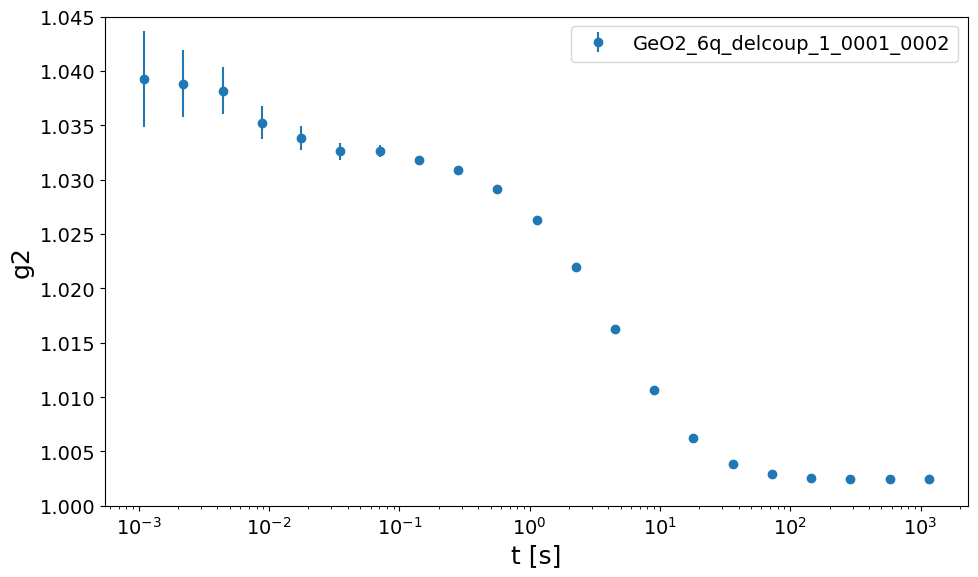

In [5]:
##################### plot a set of g2s #####################
scans = ['GeO2_6q_delcoup_1_0001_0002']
#############################################################

plt.figure(figsize=(10, 6))
for scan in scans:
    try:
        plt.scatter(x=g2s[scan][0], y=g2s[scan][1], s=.01, alpha=.4)
        t_mt, g2_mt, dg2_mt = get_g2mt_fromling2(g2s[scan][0][0], g2s[scan][1], g2s[scan][2])
        plt.errorbar(x=t_mt, y=g2_mt, yerr=dg2_mt, fmt='o', label=f'{scan}')
    except:
        plt.errorbar(x=g2mts[scan][0], y=g2mts[scan][1], yerr=g2mts[scan][2], fmt='o', label=f'{scan}')

plt.xlabel('t [s]')
plt.ylabel('g2')
plt.xscale('log')
plt.ylim(1, 1.045)
plt.legend(loc='upper right')
plt.tight_layout(); plt.show()

### Dynamics of the **stationary** damaged state

In [6]:
### Using plotly
for p in ['tau', 'beta', 'c', 'y0']:
    fig = go.Figure()
    for name, group in df2plot.groupby('ID_sample'):
        label = f'sample {name}'
        x = group['Q']
        dx = group['dQ']
        y = group[p]
        yerr = group['d'+p]

        # Color by scan: add one trace per scan
        for color_name, color_group in group.groupby(group.index):
            for marker_name, marker_group in color_group.groupby('mt_fit'):
                fig.add_trace(go.Scatter(
                    x=marker_group['Q'],
                    y=marker_group[p],
                    error_y=dict(type='data', array=marker_group['d'+p], visible=True),
                    error_x=dict(type='data', array=marker_group['dQ'], visible=True),
                    marker_symbol = 'circle' if marker_group['mt_fit'].iloc[0] else 'square',
                    marker=dict(size=15),
                    mode='markers',
                    name=f'{label}, {color_name}, mt_fit={marker_name}',
                    text=color_group.index,
                    #hovertemplate='scan: %{text}<br>Q: %{x:.2f} A-1 ± %{error_x.array:.2f}<br>'
                ))

    fig.update_layout(
        xaxis_title='Q [A-1]',
        yaxis_title=f'{p} [s]',
        legend_title='Sample, Scan',
        template='plotly_white',
        height=600,
        width=1000,
    )
    fig.show()

# Dynamics temperature dependence of the v-GeO2 X-Ray damaged glass

In [7]:
df2plot = g2fit[(g2fit['Q']==.21)]
display(df2plot)

,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,...,mt_fit,ID_sample,T,d,E,theta,fresh,ramp,test,att
scan,,,,,,,,,,,,,,,,,,,,,
GeO2_6_0001_0009,0.21,0.01,5.006553,0.099427,1.985940,0.740447,0.010391,1.403290,0.033109,0.000374,...,False,6,30,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_0001_0012,0.21,0.01,5.286614,0.051587,0.975801,0.774137,0.006176,0.797831,0.029921,0.000178,...,False,6,30,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_100C_0001_0003,0.21,0.01,4.836616,0.114193,2.361019,0.729458,0.011976,1.641805,0.028639,0.000382,...,False,6,100,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_170C_0001_0001,0.21,0.01,4.292787,0.111486,2.597062,0.747830,0.013977,1.868968,0.027286,0.000407,...,False,6,170,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_240C_0001_0003,0.21,0.01,3.635474,0.115745,3.183756,0.708906,0.014947,2.108398,0.027172,0.000479,...,False,6,240,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_310C_0001_0003,0.21,0.01,2.878277,0.104638,3.635449,0.702533,0.016607,2.363890,0.027010,0.000540,...,False,6,310,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_380C_0001_0001,0.21,0.01,2.161081,0.102689,4.751740,0.715974,0.022674,3.166871,0.024920,0.000659,...,False,6,380,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_450C_0001_0003,0.21,0.01,1.624596,0.109635,6.748422,0.632030,0.024168,3.823867,0.025974,0.000908,...,False,6,450,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_520C_0001_0001,0.21,0.01,1.422250,0.111926,7.869633,0.644611,0.029348,4.552811,0.024663,0.001017,...,False,6,520,100,9.7,0.19,NaN,heating,NaN,NaN


## View specific g2

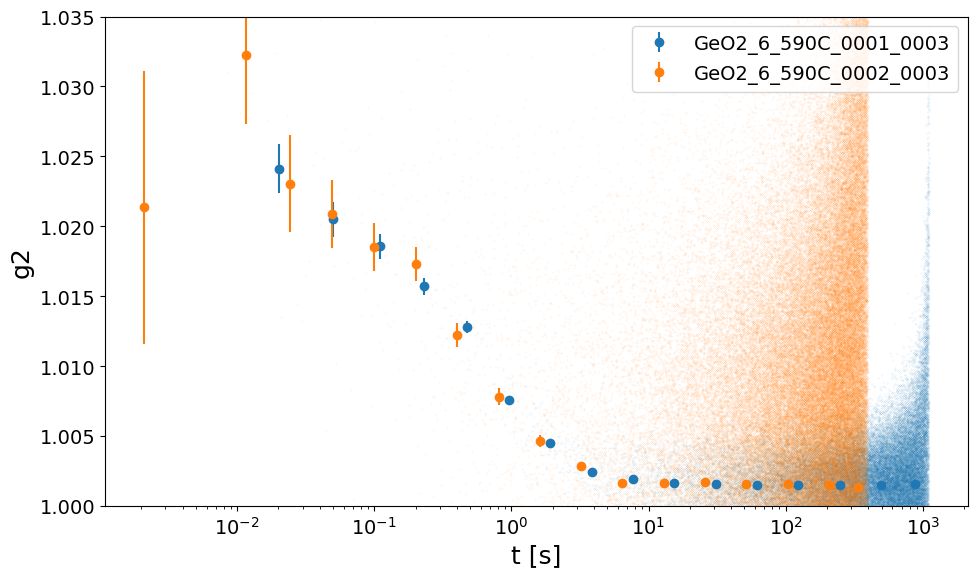

In [8]:
##################### plot a set of g2s #####################
scans = ['GeO2_6_590C_0001_0003', 'GeO2_6_590C_0002_0003']
#############################################################

plt.figure(figsize=(10, 6))
for scan in scans:
    plt.scatter(x=g2s[scan][0], y=g2s[scan][1], s=.01, alpha=.4)
    t_mt, g2_mt, dg2_mt = get_g2mt_fromling2(g2s[scan][0][0], g2s[scan][1], g2s[scan][2])
    plt.errorbar(x=t_mt, y=g2_mt, yerr=dg2_mt, fmt='o', label=f'{scan}')

plt.xlabel('t [s]')
plt.ylabel('g2')
plt.xscale('log')
plt.ylim(1, 1.035)
plt.legend(loc='upper right')
plt.tight_layout(); plt.show()


## Dynamics of the **stationary** damaged state

In [9]:
### Using plotly
for p in ['tau', 'beta', 'c', 'y0']:
    fig = go.Figure()
    for name, group in df2plot.groupby('ID_sample'):
        for subname, subgroup in group.groupby('ramp'):
            label = f'sample {name}, {subname}'
            x = subgroup['T']
            y = subgroup[p]
            yerr = subgroup['d'+p]

            fig.add_trace(go.Scatter(
                x=x, y=y,
                error_y=dict(type='data', array=yerr, visible=True),
                mode='markers',
                name=label,
                text=subgroup.index,
                hovertemplate='scan: %{text}<br>T: %{x}<br>'+f'{p}: '+'%{y:.4g}±%{error_y.array:.2g} (error percent: %{error_y.array/y:.2%}'
            ))
    fig.update_layout(
        xaxis_title='T [C]',
        yaxis_title=f'{p} [s]',
        legend_title='Sample, Ramp',
        template='plotly_white',
        height=600,
        width=1000,
    )
    fig.show()

In [10]:
###### same with matplotlib #######
'''
plt.figure(figsize=(10, 6))
for name, group in df2plot.groupby('ID_sample'):
    for subname, subgroup in group.groupby('ramp'):
        label = f'samole {name}, {subname}'
        x = subgroup['T']
        y = subgroup[p]
        yerr = subgroup['d'+p]
        plt.errorbar(x, y, yerr=yerr, label=label, fmt='o')
plt.xlabel(r'T [C]')
plt.ylabel(f'{p} [s]')
plt.legend()
plt.grid()
plt.tight_layout(), plt.show();
''';

# Dynamics Q dependence of the v-GeO2 X-Ray damaged glass

# Dynamics X-Ray attenuation dependence

# Dynamics Beamsize dependence (throught the dose) (@ Troom = 30C)

# Intensity temperature dependence of the v-GeO2 X-Ray damaged glass

In [11]:
##################
damage_th = 2e2
dI_damage = 0.003
##################

I_damage = {}
for k in Idts.keys():
    I_damage[k] = Idts[k][1][Idts[k][0] > damage_th].mean()

/tmp/ipykernel_11072/1215044662.py:8: RuntimeWarning:

Mean of empty slice.

/home/fabio/anaconda3/envs/XPCSenv/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning:

invalid value encountered in scalar divide



In [12]:
#######################
theta = .19
ID_sample = 6
q = .21
#######################

df2plot = scan_info[(scan_info['theta']==theta)&(scan_info['ID_sample']==ID_sample)]
display(df2plot)

,ID_sample,T,d,E,theta,fresh,ramp,test,att
scan,,,,,,,,,
GeO2_6_0001_0007,6,30,100,9.7,0.19,NaN,heating,True,NaN
GeO2_6_0001_0008,6,30,100,9.7,0.19,NaN,heating,True,NaN
GeO2_6_0001_0009,6,30,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_0001_0011,6,30,100,9.7,0.19,True,heating,True,NaN
GeO2_6_0001_0012,6,30,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_100C_0001_0003,6,100,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_170C_0001_0001,6,170,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_240C_0001_0003,6,240,100,9.7,0.19,NaN,heating,NaN,NaN
GeO2_6_310C_0001_0003,6,310,100,9.7,0.19,NaN,heating,NaN,NaN


Intensity file not found for scan: GeO2_6_0001_0007
Intensity file not found for scan: GeO2_6_0001_0008


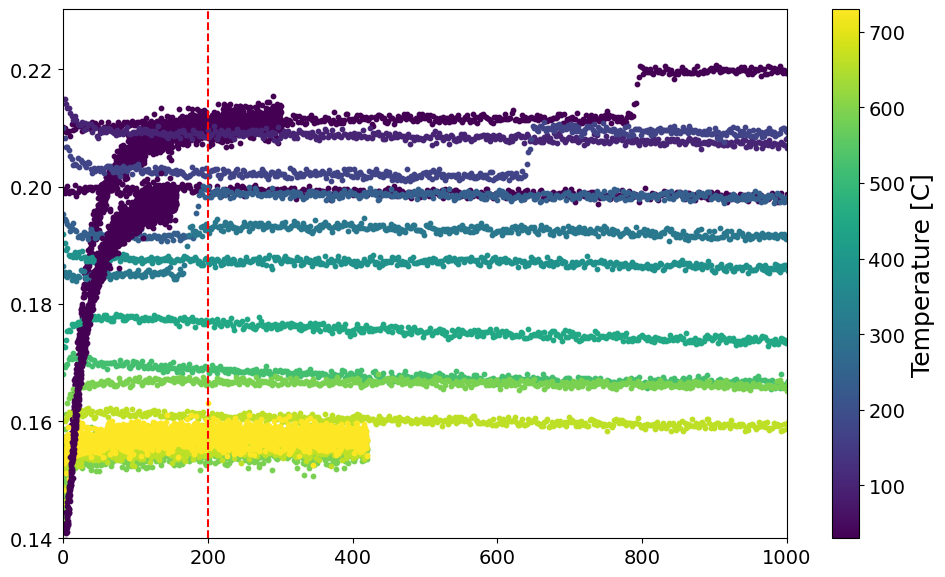

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

# Create a colormap normalized to the temperature range
norm = plt.Normalize(df2plot['T'].min(), df2plot['T'].max())
cmap = plt.cm.viridis

for s, group in df2plot.groupby('scan'):
    try:
        x = Idts[(s,q)][0]
        y = Idts[(s,q)][1]
        T = group['T'].values[0]
        color = cmap(norm(T))
        ax.scatter(x, y, s=10, alpha=1, label=f'T={T}C', color=color)
    except:
        print('Intensity file not found for scan:', s)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Temperature [C]')
ax.set_xlim(0,1000)
ax.set_ylim(0.14)
ax.axvline(damage_th, color='red', linestyle='--', label='Damage threshold')
#ax.set_xscale('log')
#ax.legend(loc='upper right')

plt.tight_layout(); plt.show()

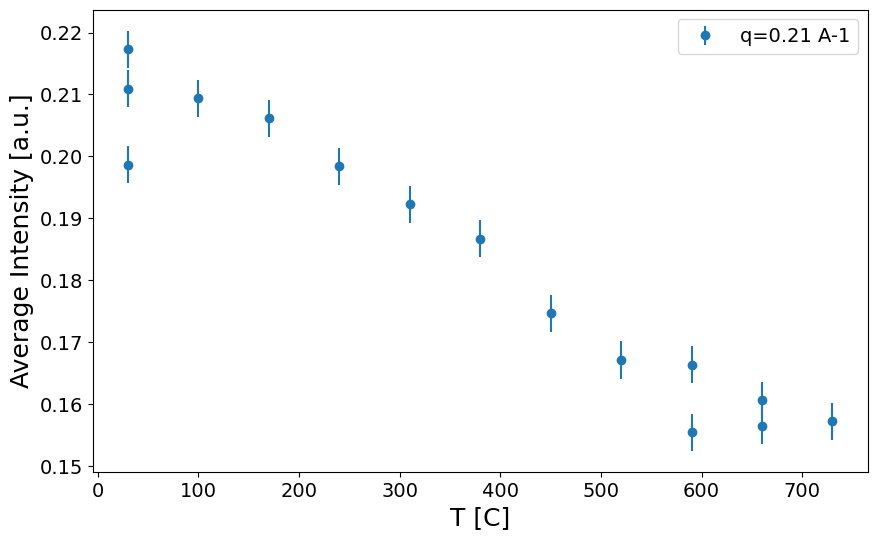

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
x, y = [], []
for k in I_damage.keys():
    if (k[1] == q) and (k[0] in df2plot.index):
        x.append(scan_info.loc[k[0]]['T'])
        y.append(I_damage[k])
dy = dI_damage
ax.errorbar(x, y, yerr=dy, fmt='o',  label=f'q={q} A-1')

ax.set_xlabel('T [C]')
ax.set_ylabel('Average Intensity [a.u.]')
plt.legend()
